In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load the dataset**: Load the concrete strength dataset from Google Drive into a pandas DataFrame.

In [ ]:
import pandas as pd

# Replace 'path/to/your/dataset.csv' with the actual path to your file in Google Drive
try:
    df = pd.read_csv('concrete_data.csv')
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print("Error: Dataset not found. Please check the path to your file.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully.


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


**Explore and preprocess the data**: Perform exploratory data analysis, handle missing values, and prepare the data for the linear regression model. This may include selecting features and splitting the data into training and testing sets.

In [ ]:
# Display basic information about the dataset
print("Dataset Info:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Assuming no missing values for now, if there were, we would handle them here
# e.g., df.dropna(inplace=True) or df.fillna(mean_value, inplace=True)

# Separate features (X) and target variable (y)
X = df.drop('concrete_compressive_strength', axis=1)
y = df['concrete_compressive_strength']

# Display the first few rows of X and y
print("\nFeatures (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   cement                         1030 non-null   float64
 1   blast_furnace_slag             1030 non-null   float64
 2   fly_ash                        1030 non-null   float64
 3   water                          1030 non-null   float64
 4   superplasticizer               1030 non-null   float64
 5   coarse_aggregate               1030 non-null   float64
 6   fine_aggregate                 1030 non-null   float64
 7   age                            1030 non-null   int64  
 8   concrete_compressive_strength  1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

Descriptive Statistics:


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000



Missing Values:
cement                           0
blast_furnace_slag               0
fly_ash                          0
water                            0
superplasticizer                 0
coarse_aggregate                 0
fine_aggregate                   0
age                              0
concrete_compressive_strength    0
dtype: int64

Features (X):


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360



Target (y):


,concrete_compressive_strength
0,79.99
1,61.89
2,40.27
3,41.05
4,44.30


**Train the Linear Regression model**: Train a Linear Regression model on the training data.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Evaluate the model**: Evaluate the performance of the trained model using appropriate metrics for regression.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test data
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Squared Error (MSE): 95.97
Root Mean Squared Error (RMSE): 9.80
R-squared (R2) Score: 0.63


**Visualize the results**: Generate various plots to visualize the model's performance and the relationship between features and the target variable. Although a confusion matrix is typically for classification, we can adapt it to visualize the distribution of predicted vs. actual values by binning them.

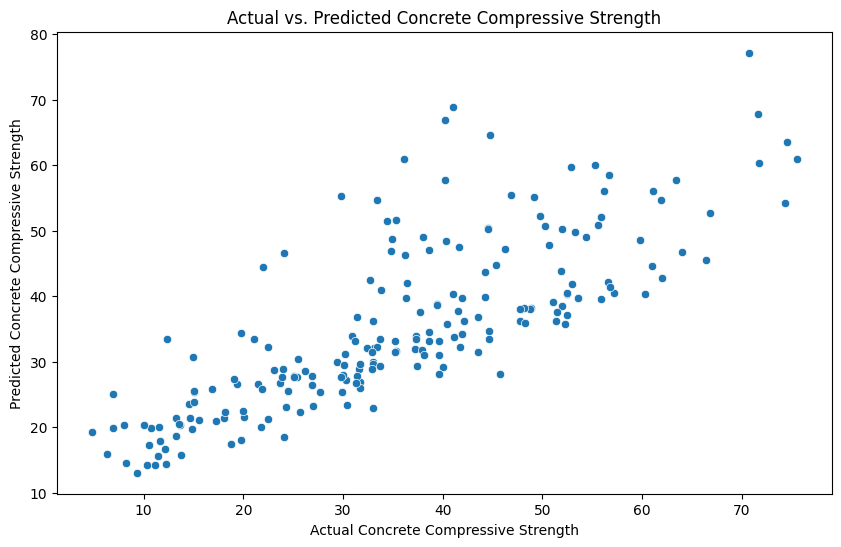

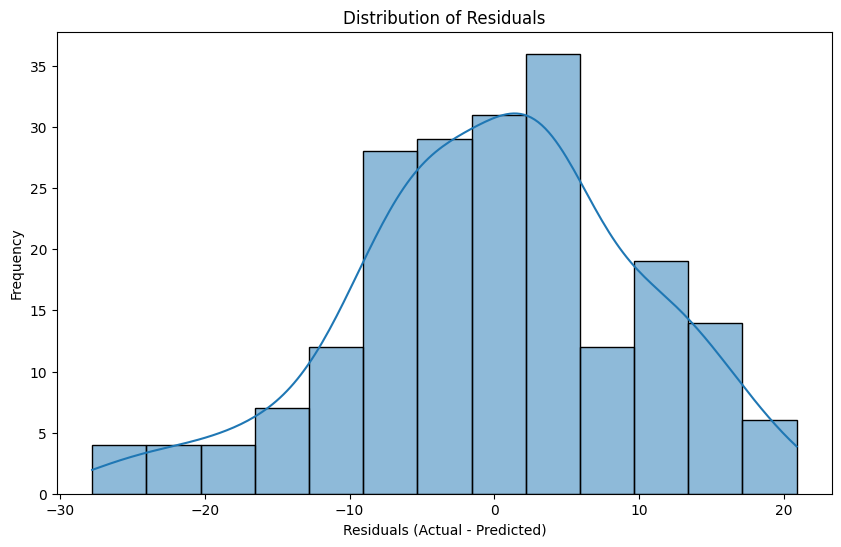

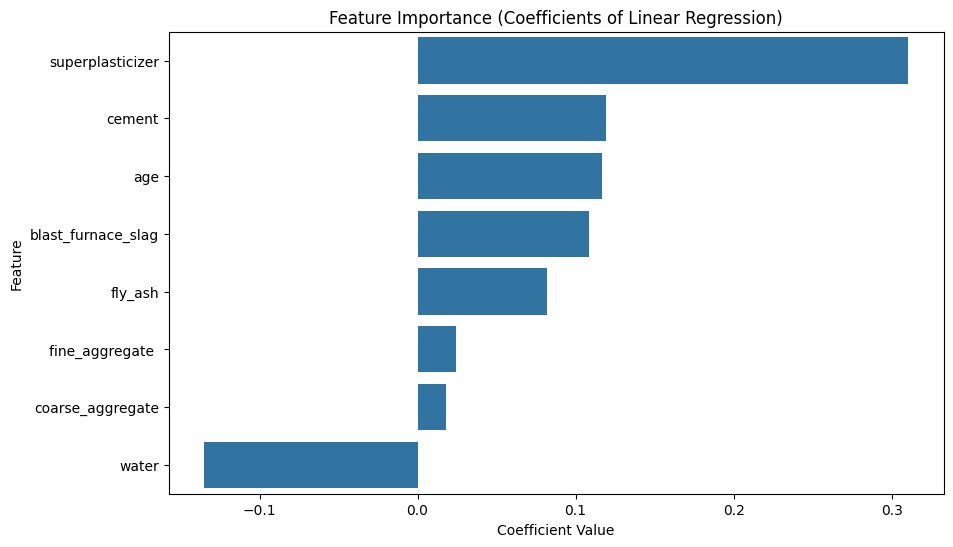

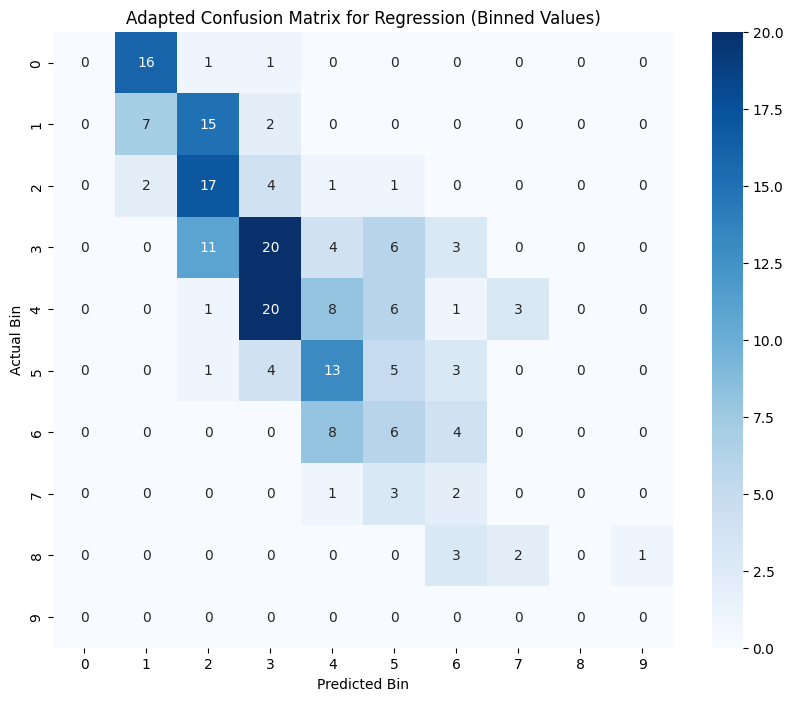

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Concrete Compressive Strength")
plt.ylabel("Predicted Concrete Compressive Strength")
plt.title("Actual vs. Predicted Concrete Compressive Strength")
plt.show()

# Histogram of residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

# Plotting feature importance (for linear regression, coefficients can indicate importance)
# Create a DataFrame for coefficients
coef_df = pd.DataFrame({'feature': X.columns, 'coefficient': model.coef_})
coef_df = coef_df.sort_values(by='coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='coefficient', y='feature', data=coef_df)
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Coefficients of Linear Regression)")
plt.show()

# Adapted "Confusion Matrix" for Regression (by binning)
# We need to bin the actual and predicted values to create a matrix
# Let's create bins based on the range of concrete strength
min_strength = min(y_test.min(), y_pred.min())
max_strength = max(y_test.max(), y_pred.max())
bins = np.linspace(min_strength, max_strength, 10) # You can adjust the number of bins

actual_binned = np.digitize(y_test, bins)
pred_binned = np.digitize(y_pred, bins)

# Create a confusion matrix like structure
# The rows will represent actual bins, columns will represent predicted bins
confusion_matrix_regression = np.zeros((len(bins), len(bins)))

for actual, pred in zip(actual_binned, pred_binned):
    # Adjust indices to be within the matrix bounds
    actual_idx = min(actual - 1, len(bins) - 1)
    pred_idx = min(pred - 1, len(bins) - 1)
    if actual_idx >= 0 and pred_idx >= 0:
        confusion_matrix_regression[actual_idx, pred_idx] += 1

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_regression, annot=True, fmt='g', cmap='Blues')
plt.xlabel("Predicted Bin")
plt.ylabel("Actual Bin")
plt.title("Adapted Confusion Matrix for Regression (Binned Values)")
plt.show()